# SSONDO Embedding Quality Evaluation

This notebook evaluates whether the SSONDO student model (MobileNetV3 distilled from MATPAC++) produces semantically meaningful audio embeddings.

**Method:**
1. Download ESC-50 (2000 environmental sounds, 50 classes) from HuggingFace
2. Extract embeddings with the SSONDO inference package
3. Cluster embeddings with KMeans
4. Evaluate cluster quality and alignment with ground-truth labels

In [1]:
import os

import numpy as np
import pandas as pd
import torch
import torchaudio
import matplotlib.pyplot as plt
from datasets import load_dataset, Audio
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    adjusted_rand_score,
)
from tqdm.auto import tqdm
from ssondo.model import get_ssondo

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

SEED = 42
TARGET_SR = 32000
CKPT_PATH = os.path.join('..', 'inference_ssondo', 'models', 'matpac++_mobilenetv3_last.ckpt')
OUTPUT_DIR = 'outputs'

np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

/Users/ma.eladlouni/projects/ssondo_temp/notebooks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 1. Load SSONDO Model

In [2]:
CKPT_PATH = os.path.join('..', 'inference_ssondo', 'models', 'matpac++_mobilenetv3_last.ckpt')
assert os.path.exists(CKPT_PATH), f'Checkpoint not found at {CKPT_PATH}'

model = get_ssondo(CKPT_PATH, device=DEVICE)
print(f'Model loaded (emb_size={model.student_model.model.emb_size})')

Model loaded (emb_size=960)


## 2. Load ESC-50 Dataset

In [3]:
ds = load_dataset('ashraq/esc50', split='train')
# Cast audio to soundfile backend at target sample rate
ds = ds.cast_column('audio', Audio(sampling_rate=TARGET_SR))
print(f'ESC-50: {len(ds)} samples')
print(f'Columns: {ds.column_names}')

class_names = sorted(set(ds['category']))
print(f'Number of classes: {len(class_names)}')

Repo card metadata block was not found. Setting CardData to empty.


ESC-50: 2000 samples
Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'audio']
Number of classes: 50


In [4]:
# Show a few examples
for i in range(3):
    sample = ds[i]
    audio = sample['audio']
    print(f"Sample {i}: category='{sample['category']}', "
          f"sr={audio['sampling_rate']}, "
          f"duration={len(audio['array']) / audio['sampling_rate']:.1f}s")

Sample 0: category='dog', sr=32000, duration=5.0s
Sample 1: category='chirping_birds', sr=32000, duration=5.0s
Sample 2: category='vacuum_cleaner', sr=32000, duration=5.0s


## 3. Extract Embeddings

In [5]:
all_embeddings = []
all_labels = []
all_categories = []

for sample in tqdm(ds, desc='Extracting embeddings'):
    audio = sample['audio']
    waveform = torch.tensor(audio['array'], dtype=torch.float32)

    # Ensure mono
    if waveform.ndim > 1:
        waveform = waveform.mean(dim=0)

    # Pad to at least 10s (SliceAudio window) if audio is shorter
    min_samples = TARGET_SR * 10
    if waveform.shape[0] < min_samples:
        waveform = torch.nn.functional.pad(waveform, (0, min_samples - waveform.shape[0]))

    # Shape: (1, n_samples)
    waveform = waveform.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        emb = model(waveform)  # (1, n_segments, 960)

    # Mean-pool over segments -> (960,)
    emb = emb.mean(dim=1).squeeze(0).cpu().numpy()

    all_embeddings.append(emb)
    all_labels.append(sample['target'])
    all_categories.append(sample['category'])

embeddings = np.stack(all_embeddings)
labels = np.array(all_labels)
categories = np.array(all_categories)

print(f'Embeddings shape: {embeddings.shape}')
print(f'Unique labels: {len(np.unique(labels))}')

Extracting embeddings: 100%|██████████| 2000/2000 [00:33<00:00, 59.86it/s]

Embeddings shape: (2000, 960)
Unique labels: 50


## 4. Visualize Embeddings

Running t-SNE...


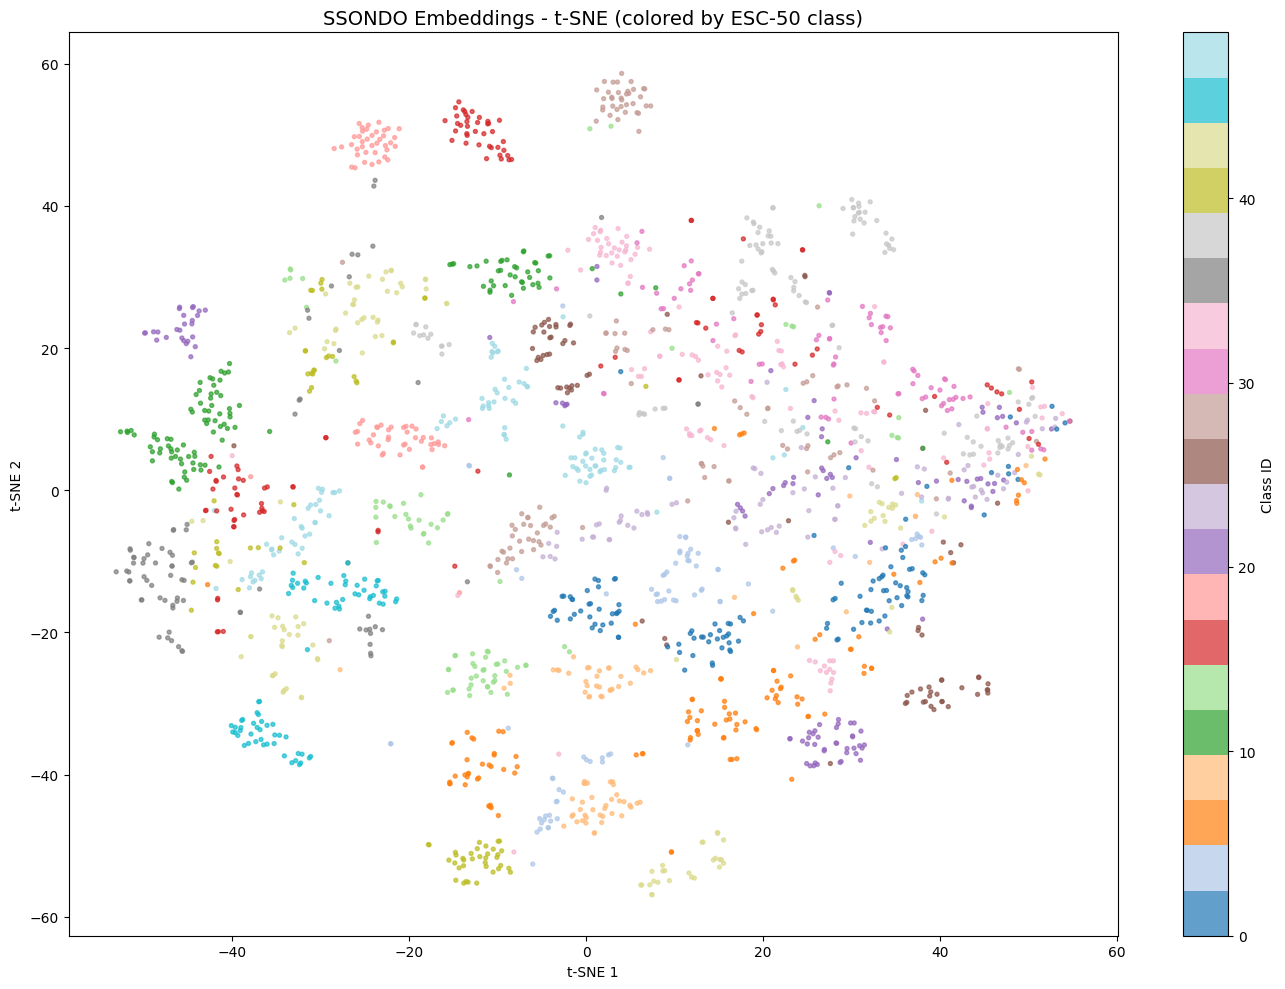

In [6]:
print('Running t-SNE...')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
emb_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=labels, cmap='tab20', s=8, alpha=0.7)
ax.set_title('SSONDO Embeddings - t-SNE (colored by ESC-50 class)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.colorbar(scatter, label='Class ID')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_by_class.png'), dpi=150)
plt.show()

Running UMAP...


/Users/ma.eladlouni/projects/ssondo_temp/notebooks/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


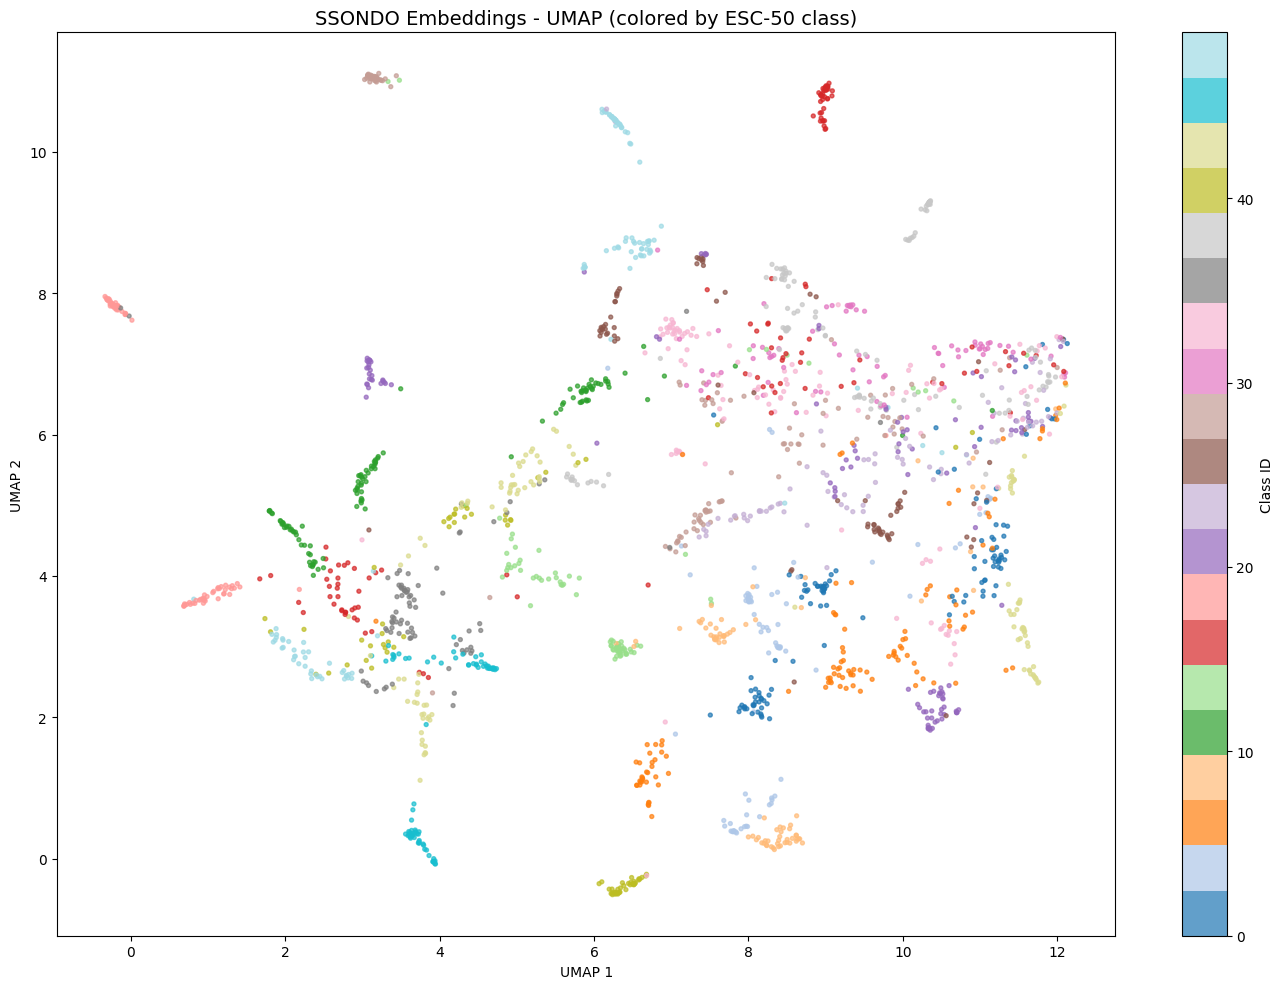

In [7]:
if HAS_UMAP:
    print('Running UMAP...')
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    emb_umap = reducer.fit_transform(embeddings)

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    scatter = ax.scatter(emb_umap[:, 0], emb_umap[:, 1],
                         c=labels, cmap='tab20', s=8, alpha=0.7)
    ax.set_title('SSONDO Embeddings - UMAP (colored by ESC-50 class)', fontsize=14)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    plt.colorbar(scatter, label='Class ID')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'umap_by_class.png'), dpi=150)
    plt.show()
else:
    print('umap-learn not installed, skipping UMAP visualization')

## 5. K-Means Clustering

In [8]:
N_CLUSTERS = 50  # same as number of ESC-50 classes

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

print(f'KMeans fitted with k={N_CLUSTERS}')
print(f'Inertia: {kmeans.inertia_:.2f}')

KMeans fitted with k=50
Inertia: 1008.14


## 6. Clustering Metrics

In [9]:
# Unsupervised metrics (embedding quality)
sil = silhouette_score(embeddings, cluster_labels)
ch = calinski_harabasz_score(embeddings, cluster_labels)
db = davies_bouldin_score(embeddings, cluster_labels)

# Supervised metrics (cluster-label alignment)
nmi = normalized_mutual_info_score(labels, cluster_labels)
ari = adjusted_rand_score(labels, cluster_labels)

print('=' * 60)
print('CLUSTERING EVALUATION RESULTS')
print('=' * 60)
print(f'{"Silhouette Score":>35s}: {sil:>10.4f}  (higher is better, max 1.0)')
print(f'{"Calinski-Harabasz Index":>35s}: {ch:>10.1f}  (higher is better)')
print(f'{"Davies-Bouldin Index":>35s}: {db:>10.4f}  (lower is better)')
print(f'{"Normalized Mutual Information":>35s}: {nmi:>10.4f}  (higher is better, max 1.0)')
print(f'{"Adjusted Rand Index":>35s}: {ari:>10.4f}  (higher is better, max 1.0)')
print('=' * 60)

CLUSTERING EVALUATION RESULTS
                   Silhouette Score:     0.1079  (higher is better, max 1.0)
            Calinski-Harabasz Index:       44.8  (higher is better)
               Davies-Bouldin Index:     2.2116  (lower is better)
      Normalized Mutual Information:     0.6646  (higher is better, max 1.0)
                Adjusted Rand Index:     0.3579  (higher is better, max 1.0)


## 7. Cluster Purity Analysis

In [10]:
# Build contingency table
contingency = pd.crosstab(
    pd.Series(cluster_labels, name='Cluster'),
    pd.Series(categories, name='Category'),
)

# Compute per-cluster purity
cluster_info = []
for cluster_id in range(N_CLUSTERS):
    if cluster_id not in contingency.index:
        continue
    row = contingency.loc[cluster_id]
    dominant_class = row.idxmax()
    dominant_count = row.max()
    total = row.sum()
    purity = dominant_count / total
    cluster_info.append({
        'Cluster': cluster_id,
        'Size': total,
        'Dominant Class': dominant_class,
        'Dominant Count': dominant_count,
        'Purity': purity,
    })

df_clusters = pd.DataFrame(cluster_info).sort_values('Purity', ascending=False)

# Overall purity (weighted by cluster size)
overall_purity = (df_clusters['Dominant Count'].sum() / df_clusters['Size'].sum())

print(f'Overall Cluster Purity: {overall_purity:.4f}\n')
print('Top 15 purest clusters:')
print(df_clusters.head(15).to_string(index=False))
print(f'\nBottom 5 clusters:')
print(df_clusters.tail(5).to_string(index=False))

Overall Cluster Purity: 0.5580

Top 15 purest clusters:
 Cluster  Size  Dominant Class  Dominant Count   Purity
      22     5           siren               5 1.000000
      41    16            frog              16 1.000000
      28    21        clapping              21 1.000000
      26    22         insects              22 1.000000
      27    25    church_bells              25 1.000000
      40    36   pouring_water              35 0.972222
      34    39  brushing_teeth              37 0.948718
      46    37        chainsaw              35 0.945946
      24    18     clock_alarm              17 0.944444
       7    35            rain              32 0.914286
      16    39  chirping_birds              35 0.897436
      10    38        hand_saw              34 0.894737
       4    43    toilet_flush              37 0.860465
       2    35             pig              29 0.828571
      45    40 keyboard_typing              33 0.825000

Bottom 5 clusters:
 Cluster  Size Dominant Clas

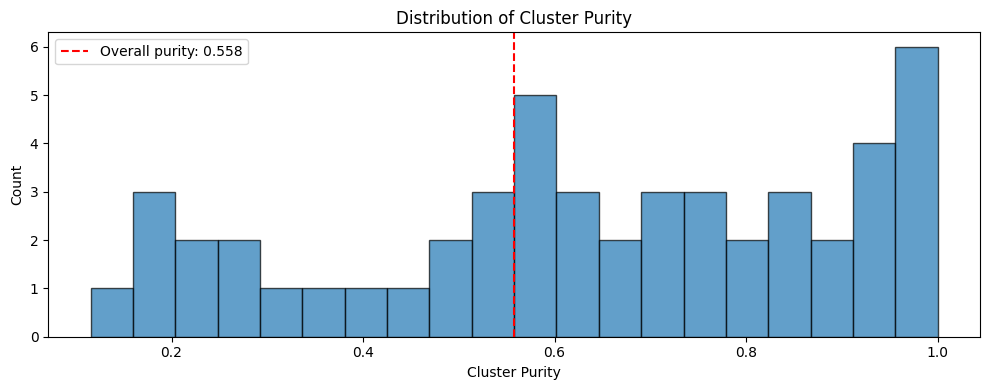

In [11]:
# Purity distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_clusters['Purity'], bins=20, edgecolor='black', alpha=0.7)
ax.axvline(overall_purity, color='red', linestyle='--', label=f'Overall purity: {overall_purity:.3f}')
ax.set_xlabel('Cluster Purity')
ax.set_ylabel('Count')
ax.set_title('Distribution of Cluster Purity')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'purity_distribution.png'), dpi=150)
plt.show()

## 8. Per-Category Analysis (5 major ESC-50 groups)

In [12]:
# ESC-50 major categories (classes 0-9: Animals, 10-19: Natural, etc.)
MAJOR_CATEGORIES = {
    'Animals': list(range(0, 10)),
    'Natural soundscapes': list(range(10, 20)),
    'Human (non-speech)': list(range(20, 30)),
    'Domestic / Interior': list(range(30, 40)),
    'Urban / Exterior': list(range(40, 50)),
}

# Map each sample to its major category
label_to_major = {}
for major_name, label_ids in MAJOR_CATEGORIES.items():
    for lid in label_ids:
        label_to_major[lid] = major_name

major_labels = np.array([label_to_major.get(l, 'Unknown') for l in labels])
major_names_ordered = list(MAJOR_CATEGORIES.keys())

print('Major categories and sample counts:')
for name in major_names_ordered:
    count = (major_labels == name).sum()
    print(f'  {name}: {count} samples')

Major categories and sample counts:
  Animals: 400 samples
  Natural soundscapes: 400 samples
  Human (non-speech): 400 samples
  Domestic / Interior: 400 samples
  Urban / Exterior: 400 samples


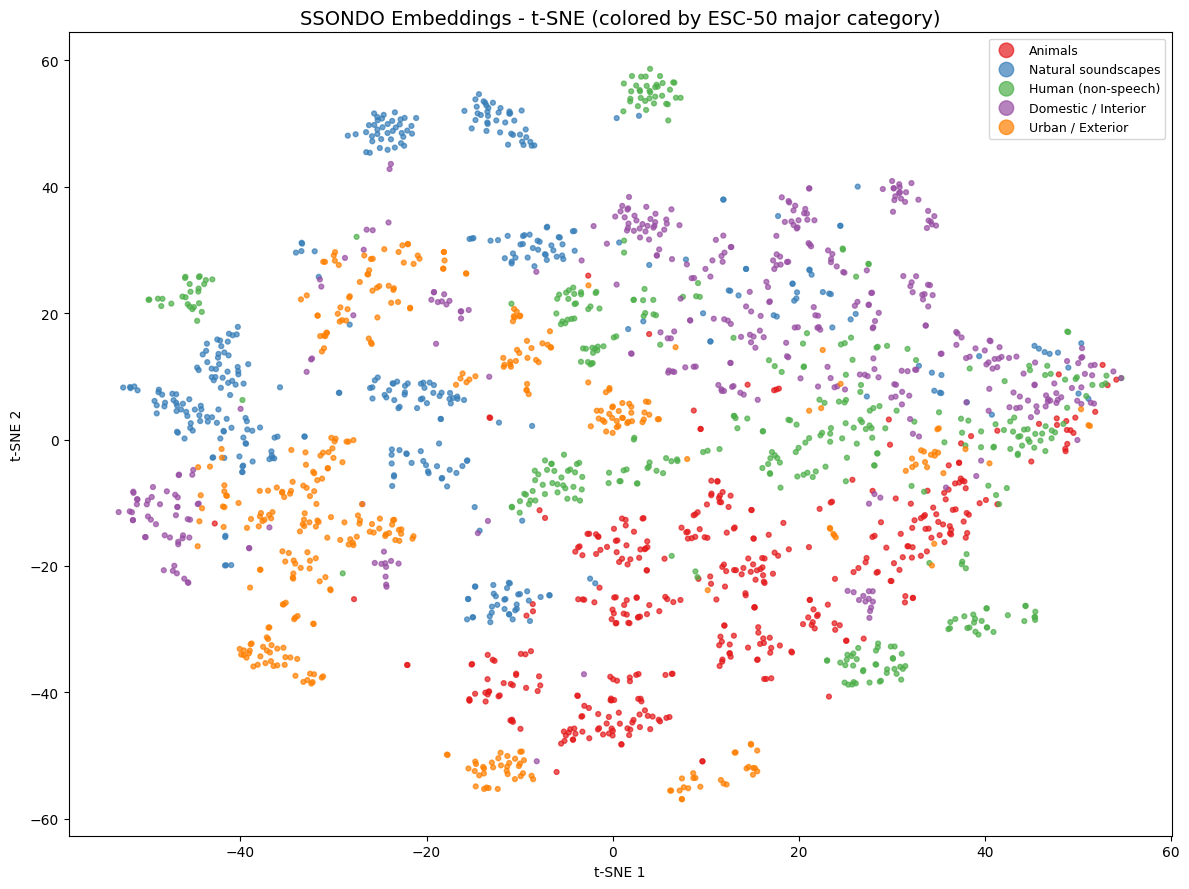

In [13]:
# t-SNE colored by major category
fig, ax = plt.subplots(1, 1, figsize=(12, 9))
cmap = plt.cm.Set1
for i, name in enumerate(major_names_ordered):
    mask = major_labels == name
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[cmap(i)] * mask.sum(), s=12, alpha=0.7, label=name)

ax.set_title('SSONDO Embeddings - t-SNE (colored by ESC-50 major category)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(loc='best', fontsize=9, markerscale=3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_by_major_category.png'), dpi=150)
plt.show()

In [14]:
# KMeans with k=5 for major categories
colors_major = {name: i for i, name in enumerate(major_names_ordered)}
major_label_ids = np.array([colors_major[m] for m in major_labels])

kmeans_5 = KMeans(n_clusters=5, random_state=SEED, n_init=10)
cluster_labels_5 = kmeans_5.fit_predict(embeddings)

nmi_5 = normalized_mutual_info_score(major_label_ids, cluster_labels_5)
ari_5 = adjusted_rand_score(major_label_ids, cluster_labels_5)
sil_5 = silhouette_score(embeddings, cluster_labels_5)

print('Major Category Clustering (k=5):')
print(f'  NMI:        {nmi_5:.4f}')
print(f'  ARI:        {ari_5:.4f}')
print(f'  Silhouette: {sil_5:.4f}')

Major Category Clustering (k=5):
  NMI:        0.1270
  ARI:        0.1031
  Silhouette: 0.1162


## 9. Classification Evaluation (clusters as predicted labels)

We use the **Hungarian algorithm** to find the optimal one-to-one mapping from cluster IDs to true class labels (maximizing total correct assignments), then evaluate standard classification metrics.

In [ ]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# --- Fine-grained: k=50 clusters -> 50 classes ---

# Build cost matrix: (n_clusters x n_classes), where cost = -count of matches
unique_labels = np.unique(labels)
cost_matrix = np.zeros((N_CLUSTERS, len(unique_labels)), dtype=int)
for i in range(N_CLUSTERS):
    mask_cluster = cluster_labels == i
    for j, true_label in enumerate(unique_labels):
        cost_matrix[i, j] = np.sum(labels[mask_cluster] == true_label)

# Hungarian algorithm: find optimal cluster->class mapping (maximize matches = minimize -matches)
row_ind, col_ind = linear_sum_assignment(-cost_matrix)

# Build mapping: cluster_id -> true_label
cluster_to_class = {}
for r, c in zip(row_ind, col_ind):
    cluster_to_class[r] = unique_labels[c]

# Map cluster predictions to class predictions
predicted_labels = np.array([cluster_to_class.get(c, -1) for c in cluster_labels])

# Classification metrics
acc = accuracy_score(labels, predicted_labels)
prec_macro = precision_score(labels, predicted_labels, average='macro', zero_division=0)
rec_macro = recall_score(labels, predicted_labels, average='macro', zero_division=0)
f1_macro = f1_score(labels, predicted_labels, average='macro', zero_division=0)
f1_weighted = f1_score(labels, predicted_labels, average='weighted', zero_division=0)

print('=' * 60)
print('CLASSIFICATION FROM CLUSTERING (k=50, Hungarian mapping)')
print('=' * 60)
print(f'  Accuracy:              {acc:.4f}')
print(f'  Precision (macro):     {prec_macro:.4f}')
print(f'  Recall (macro):        {rec_macro:.4f}')
print(f'  F1 Score (macro):      {f1_macro:.4f}')
print(f'  F1 Score (weighted):   {f1_weighted:.4f}')
print('=' * 60)

In [ ]:
# Per-class classification report
label_to_category = {}
for sample in ds:
    label_to_category[sample['target']] = sample['category']

target_names = [label_to_category[l] for l in sorted(label_to_category.keys())]
print(classification_report(labels, predicted_labels, target_names=target_names, zero_division=0))

In [ ]:
# Confusion matrix heatmap
cm = confusion_matrix(labels, predicted_labels)

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix (Hungarian-mapped clusters vs true labels)', fontsize=14)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_xticks(range(len(target_names)))
ax.set_yticks(range(len(target_names)))
ax.set_xticklabels(target_names, rotation=90, fontsize=7)
ax.set_yticklabels(target_names, fontsize=7)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 10. Summary

In [ ]:
print('=' * 60)
print('SSONDO EMBEDDING QUALITY EVALUATION - SUMMARY')
print('=' * 60)
print(f'Model:   MATPAC++ -> MobileNetV3 (distilled)')
print(f'Dataset: ESC-50 ({len(ds)} samples, 50 classes)')
print(f'Embedding dim: {embeddings.shape[1]}')
print()
print('--- Fine-grained clustering (k=50) ---')
print(f'  Silhouette Score:  {sil:>8.4f}')
print(f'  Calinski-Harabasz: {ch:>8.1f}')
print(f'  Davies-Bouldin:    {db:>8.4f}')
print(f'  NMI:               {nmi:>8.4f}')
print(f'  ARI:               {ari:>8.4f}')
print(f'  Cluster Purity:    {overall_purity:>8.4f}')
print()
print('--- Classification from clustering (Hungarian) ---')
print(f'  Accuracy:          {acc:>8.4f}')
print(f'  Precision (macro): {prec_macro:>8.4f}')
print(f'  Recall (macro):    {rec_macro:>8.4f}')
print(f'  F1 (macro):        {f1_macro:>8.4f}')
print(f'  F1 (weighted):     {f1_weighted:>8.4f}')
print()
print('--- Coarse clustering (k=5, major categories) ---')
print(f'  NMI:               {nmi_5:>8.4f}')
print(f'  ARI:               {ari_5:>8.4f}')
print(f'  Silhouette:        {sil_5:>8.4f}')
print('=' * 60)
print(f'\nPlots saved to {OUTPUT_DIR}/')